# Adult Income Prediction using Machine Learning

## Executive Summary

The objective of this project is to develop a baseline machine learning workflow for predicting whether an individual's annual income exceeds **$50,000** using demographic and employment-related information from the UCI Adult Census Income dataset.

This notebook follows a structured machine learning pipeline:

- Problem Definition
- Data Loading & Cleaning
- Exploratory Data Analysis (EDA)
- Hold-Out Train/Test Split
- Baseline Model Development
- Model Evaluation
- Error Analysis
- Future Recommendations

The purpose of this notebook is to establish reliable baseline models that future machine learning algorithms can outperform.

## Business Context

Many organizations need to identify customers with higher purchasing power.

Accurate income prediction supports several business applications, including:

- Targeted marketing campaigns
- Premium product recommendations
- Customer segmentation
- Credit risk screening

By accurately identifying high-income individuals, businesses can improve campaign effectiveness while reducing unnecessary marketing costs.

## Dataset Description

**Dataset:** Adult Census Income Dataset

**Source:** UCI Machine Learning Repository (Available through OpenML)

**Number of Records:** 48,842

**Input Features:** 14

**Target Variable:** Income

Class Labels

Income ≤ $50K → 0

Income > $50K → 1

This is a supervised binary classification problem.

## Project Workflow

```
Adult Dataset
      │
      ▼
Data Cleaning
      │
      ▼
Exploratory Data Analysis
      │
      ▼
Train/Test Split
      │
      ▼
Baseline Models
      │
      ▼
Performance Evaluation
      │
      ▼
Error Analysis
      │
      ▼
Future Improvements
```

# Import Libraries

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Load Dataset

The Adult Census Income dataset is loaded from OpenML using Scikit-Learn. This dataset contains demographic and employment-related information that will be used to predict whether an individual's annual income exceeds **$50,000**.

In [2]:
adult = fetch_openml(
    name="adult",
    version=2,
    as_frame=True
)

df = adult.frame.copy()

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (48842, 15)


# Initial Data Inspection

Before building any machine learning model, it is important to inspect the dataset to understand its size, feature types, and overall structure. This step helps identify numerical and categorical variables and highlights any preprocessing required before model development.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


In [5]:
df.dtypes

,0
age,int64
workclass,category
fnlwgt,int64
education,category
education-num,int64
marital-status,category
occupation,category
relationship,category
race,category
sex,category


# Data Cleaning



In [6]:
(df == '?').sum().sum()

np.int64(0)

We first checked for the original '?' missing value indicator. Since the OpenML version of the Adult dataset already stores missing values as NaN, no '?' values were found. The replacement step is included as a precaution and for compatibility with the original UCI dataset.

The target variable is also converted into binary values suitable for machine learning algorithms.

In [7]:
# Replace '?' with NaN
df.replace("?", np.nan, inplace=True)

# Convert target variable to binary labels
df["class"] = (
    df["class"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .map({
        "<=50K": 0,
        ">50K": 1
    })
)

In [8]:
df["class"].value_counts()

,count
class,
0,37155
1,11687


# Task 1: Problem Definition & Success Metric

## Problem Definition

The objective of this project is to predict whether an individual's annual income exceeds **$50,000**.

This is a **binary classification** problem where:

- **0** → Income ≤ $50K

- **1** → Income > $50K

The positive class represents individuals earning more than **$50,000 per year**.


## Compute the Class Base Rate

In [9]:
positive_rate = df["class"].mean() * 100
negative_rate = 100 - positive_rate

print(f"Positive Class (>50K): {positive_rate:.2f}%")
print(f"Negative Class (<=50K): {negative_rate:.2f}%")

Positive Class (>50K): 23.93%
Negative Class (<=50K): 76.07%


## Business Objective

The business objective is to identify individuals who are likely to earn more than **$50,000** so that organizations can target premium products and marketing campaigns more effectively.

Reducing unnecessary outreach saves marketing costs while improving the overall efficiency of customer engagement strategies.

## Selected Evaluation Metric: Precision (Precision@top-k)

The Adult Income dataset is **imbalanced**, with approximately **24% of individuals earning more than \$50,000 per year (positive class)** and **76% earning \$50,000 or less (negative class)**. Because most records belong to the negative class, relying only on **Accuracy** can be misleading, as a model predicting only the majority class could still achieve high accuracy while failing to identify high-income individuals.

For this business problem, **Precision** is selected as the primary evaluation metric. The objective is to identify customers who are genuinely likely to earn more than \$50,000 while minimizing **false positive predictions**. Contacting customers who are incorrectly classified as high-income increases marketing costs and reduces campaign efficiency. Therefore, a higher Precision ensures that most customers predicted as high-income truly belong to the target group, making marketing campaigns more effective and cost-efficient.

Framing as Precision@top-k: For the rule-based baseline, the predicted-positive group (individuals with capital-gain > 0) constitutes the "top-k" selection, since this baseline has no ranking score to sort by. Precision is measured within this selected group — reflecting a realistic business constraint where marketing outreach is limited to a fixed number of contacted individuals. Once probability-based models are introduced later in the project, this framework will extend naturally: predictions will be ranked by confidence score, and precision will be evaluated over the top-k highest-confidence candidates, where k is set according to the available outreach budget.

## Precision vs Recall

Precision and Recall often have a trade-off.

- **Higher Precision** reduces false positives but may miss some true high-income individuals.
- **Higher Recall** identifies more high-income individuals but may also increase false positives.

For this business scenario, **Precision is preferred** because minimizing wasted marketing resources is more important than contacting every potential high-income customer.

## Stakeholder Explanation

Our goal is to identify customers who are most likely to earn more than **$50,000** annually. This allows marketing campaigns to focus on customers who are more likely to qualify for premium products. We selected **Precision** as the primary evaluation metric because it helps reduce unnecessary marketing costs by ensuring that most customers predicted as high-income actually belong to that group.

# Task 2: Data Loading & Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the dataset before building machine learning models.

The objectives of this section are:

- Examine dataset structure
- Identify missing values
- Explore numerical and categorical features
- Understand the target class distribution
- Discover patterns that may influence model performance

## Dataset Shapes

In [10]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 48842
Columns : 15


## Column Types

In [11]:
numeric_cols = df.select_dtypes(include="number").columns

categorical_cols = df.select_dtypes(include=["object", "category"]).columns

print("Numerical Features")
print(numeric_cols)

print("\nCategorical Features")
print(categorical_cols)

Numerical Features
Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'class'],
      dtype='object')

Categorical Features
Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object')


## Missing Values


In [12]:
missing_values = df.isnull().sum()

missing_values

,0
age,0
workclass,2799
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,2809
relationship,0
race,0
sex,0


### Observation

Missing values are present only in:

- Workclass
- Occupation
- Native Country

These variables will require preprocessing before training machine learning models.

Numeric Summary

In [13]:
numeric_summary = df.describe()

numeric_summary

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,class
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382,0.239282
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444,0.426649
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000


Value Counts

In [14]:
for col in categorical_cols:

    print("-"*60)
    print(col)

    print(df[col].value_counts(dropna=False))

    print()

------------------------------------------------------------
workclass
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
NaN                  2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

------------------------------------------------------------
education
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

------------------------------------------------------------
marital-status
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated     

## Distribution of Numerical Features

Histograms are used to visualize the distribution of numerical variables.

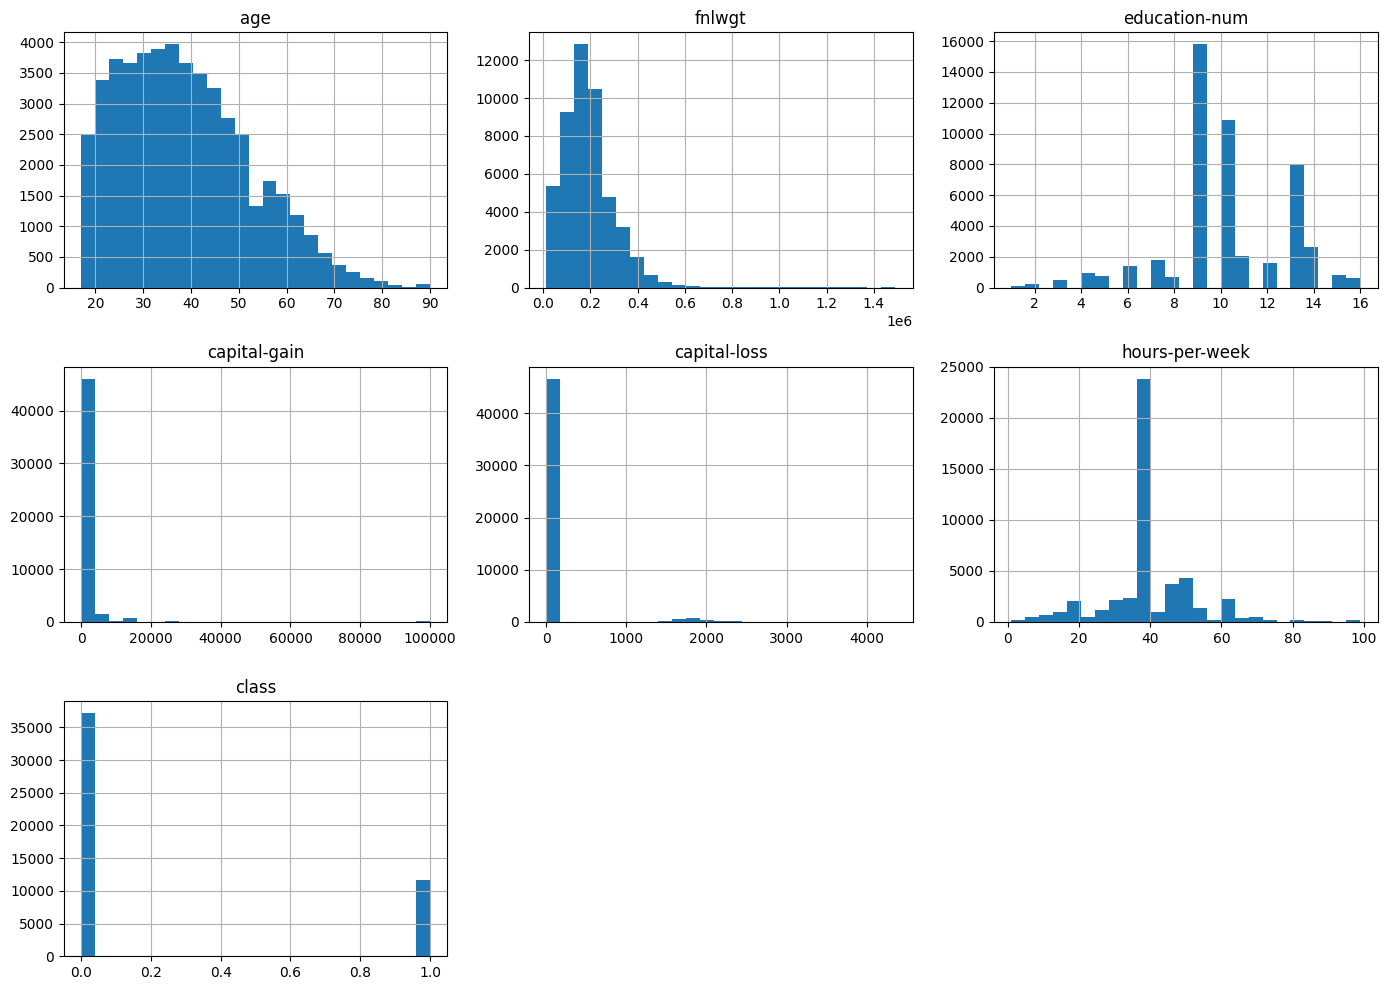

In [15]:
df[numeric_cols].hist(
    figsize=(14,10),
    bins=25
)

plt.tight_layout()

plt.show()

### Histogram Observations

- Age is concentrated between 25 and 50 years.
- Most individuals work approximately 40 hours per week.
- Capital Gain and Capital Loss are highly skewed.
- Education Number follows an approximately discrete distribution.

## Distribution of Education Levels

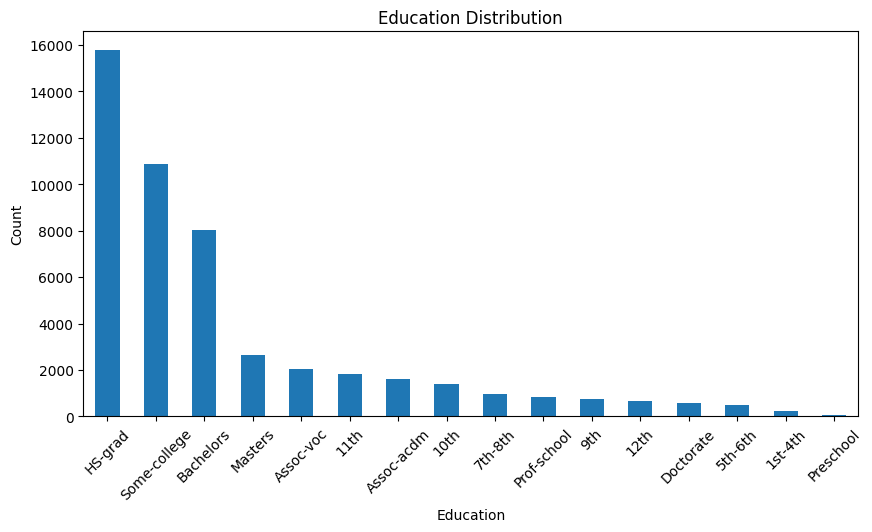

In [16]:
plt.figure(figsize=(10,5))

df["education"].value_counts().plot(kind="bar")

plt.title("Education Distribution")

plt.xlabel("Education")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

### Observation

Most individuals have completed **High School (HS-grad)**, while advanced education levels such as Doctorate and Professional School are comparatively rare.

## Distribution of Workclass

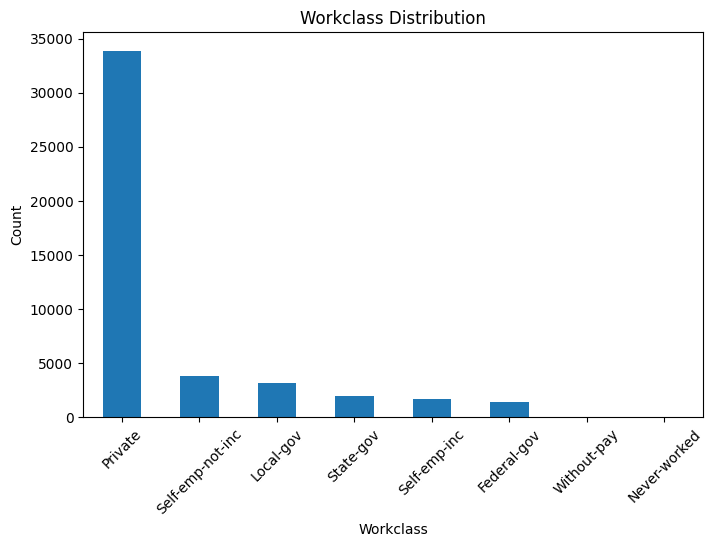

In [17]:
plt.figure(figsize=(8,5))

df["workclass"].value_counts().plot(kind="bar")

plt.title("Workclass Distribution")

plt.xlabel("Workclass")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

### Observation

Most individuals work in the **Private** sector, while government and self-employed categories are less common.

## Distribution of Occupation

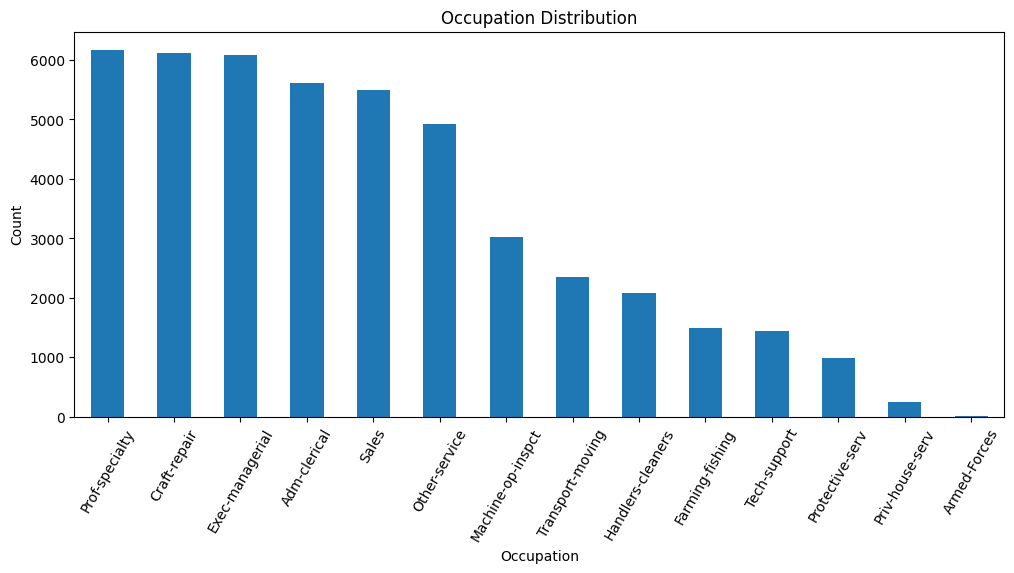

In [18]:
plt.figure(figsize=(12,5))

df["occupation"].value_counts().plot(kind="bar")

plt.title("Occupation Distribution")

plt.xlabel("Occupation")

plt.ylabel("Count")

plt.xticks(rotation=60)

plt.show()

### Observation

Professional Specialty, Craft Repair, and Executive Managerial occupations represent a significant portion of the dataset.

## Target Class Distribution

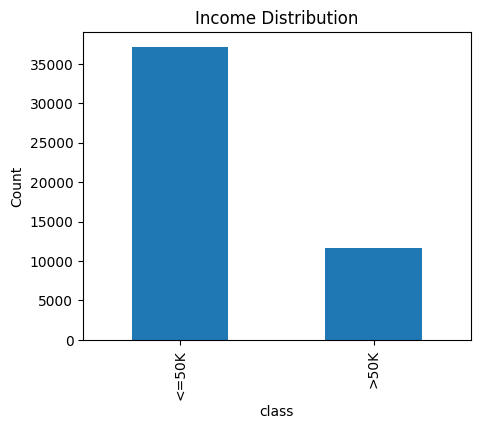

In [19]:
plt.figure(figsize=(5,4))

df["class"].value_counts().plot(kind="bar")

plt.xticks([0,1],["<=50K",">50K"])

plt.title("Income Distribution")

plt.ylabel("Count")

plt.show()

### Observation

The dataset is imbalanced.

Approximately 76% of individuals belong to the low-income class (<=50K), while only 24% belong to the high-income class (>50K).

This imbalance reinforces the importance of using Precision instead of Accuracy as the primary evaluation metric.


Summary Table

In [20]:
summary_table = pd.DataFrame({
    "Metric":[
        "Total Samples",
        "Positive (>50K)",
        "Negative (<=50K)",
        "Average Age",
        "Average Hours per Week",
        "Most Common Education",
        "Most Common Workclass",
        "Most Common Occupation",
        "Missing Workclass",
        "Missing Occupation",
        "Missing Native Country"
    ],

    "Value":[
        len(df),
        (df["class"]==1).sum(),
        (df["class"]==0).sum(),
        round(df["age"].mean(),2),
        round(df["hours-per-week"].mean(),2),

        df["education"].mode()[0],
        df["workclass"].mode()[0],
        df["occupation"].mode()[0],

        df["workclass"].isna().sum(),
        df["occupation"].isna().sum(),
        df["native-country"].isna().sum()
    ]
})
summary_table

,Metric,Value
0,Total Samples,48842
1,Positive (>50K),11687
2,Negative (<=50K),37155
3,Average Age,38.64
4,Average Hours per Week,40.42
5,Most Common Education,HS-grad
6,Most Common Workclass,Private
7,Most Common Occupation,Prof-specialty
8,Missing Workclass,2799
9,Missing Occupation,2809


## Key Findings from EDA

The exploratory data analysis revealed several important insights:

1. The dataset contains **48,842 records** and **15 variables**.

2. The target variable is imbalanced, with approximately **24%** positive samples.

3. Missing values are present in the **Workclass**, **Occupation**, and **Native Country** features.

4. The majority of individuals work approximately **40 hours per week**.

5. Most individuals have **High School (HS-grad)** as their highest education level.

6. Capital Gain and Capital Loss exhibit highly skewed distributions, suggesting that feature transformation may improve future model performance.

# Task 3: Create Reproducible Data Splits

Before training any machine learning model, the dataset is divided into separate subsets.

The data is split into:

- **Training Set (80%)** → Used to train the model.
- **Hold-Out Test Set (20%)** → Used only for final evaluation.

A **stratified split** is used to preserve the original class distribution in both datasets. A fixed **random_state** ensures that the split is reproducible.

## Seprate features and target

In [21]:
# Features
X = df.drop("class", axis=1)

# Target
y = df["class"]

## Create Holdout test set

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Verify Dataset sizes

In [23]:
print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (39073, 14)
Testing Set  : (9769, 14)


## Verify Class Distribution

In [24]:
train_distribution = y_train.value_counts(normalize=True) * 100
test_distribution = y_test.value_counts(normalize=True) * 100

distribution = pd.DataFrame({
    "Training (%)": train_distribution.round(2),
    "Testing (%)": test_distribution.round(2)
})

distribution

,Training (%),Testing (%)
class,,
0,76.07,76.07
1,23.93,23.93


## Development Set

In [25]:
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train,
    y_train,
    test_size=0.10,
    random_state=42,
    stratify=y_train
)

print("Training :", X_train.shape)
print("Development :", X_dev.shape)
print("Testing :", X_test.shape)

Training : (35165, 14)
Development : (3908, 14)
Testing : (9769, 14)


## Why Use a Hold-Out Test Set?

The hold-out test set provides an unbiased estimate of how well a machine learning model performs on unseen data. It must remain completely separate from the model development process.

Using the test set during hyperparameter tuning or model selection causes information leakage. This leads to overly optimistic performance estimates because the model becomes indirectly optimized for the test data rather than truly unseen data.

# Task 4: Baseline Models

Baseline models provide a reference point for evaluating future machine learning models.

Two baseline approaches are implemented:

1. **Majority-Class Predictor:** Always predicts the most frequent class.
2. **Rule-Based Classifier:** Uses a simple feature-based decision rule.

Future models should demonstrate clear improvement over these baselines.

## Majority Class Baseline

In [26]:
dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

## Evaluation Function

In [27]:
def evaluate_model(y_true, y_pred):

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_pred),
        "PR AUC": average_precision_score(y_true, y_pred)
    }

## Evaluation Majority Baseline

In [28]:
majority_results = evaluate_model(
    y_test,
    y_pred_dummy
)

pd.DataFrame(
    majority_results,
    index=["Majority Baseline"]
)

,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
Majority Baseline,0.760672,0.0,0.0,0.0,0.5,0.239328


## Confusion Matrix

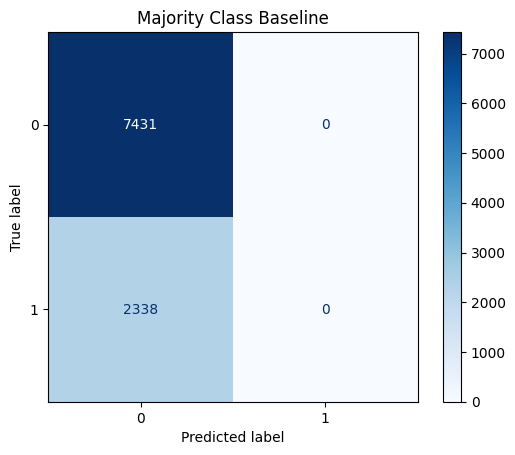

In [29]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dummy,
    cmap="Blues"
)

plt.title("Majority Class Baseline")

plt.show()

### Interpretation of Majority-Class Baseline

The majority-class classifier predicts every individual as belonging to the most common income group (≤ $50K).

Although this baseline achieves an accuracy of approximately **76%**, it fails to identify any high-income individuals. Consequently, its Precision, Recall, and F1-score are all zero, demonstrating that accuracy alone is not a reliable performance measure for imbalanced datasets.

This baseline serves as the minimum benchmark that all future machine learning models should surpass.

# Rule-Based Baseline

In addition to the majority-class predictor, we implement a simple rule-based classifier.

### Rule

Predict **Income > $50K** if:

> **capital-gain > 0**

Otherwise predict:

> **Income ≤ $50K**

### Why this rule?

Individuals reporting capital gains are generally more likely to belong to the higher-income group. Although this rule is simple, it captures a meaningful relationship between investment income and annual earnings, making it a stronger baseline than random or majority-class predictions.

## Rule Base Prediction

In [30]:
y_pred_rule = (X_test["capital-gain"] > 0).astype(int)

## Evaluation Rule Baseline

In [31]:
rule_results = evaluate_model(
    y_test,
    y_pred_rule
)

pd.DataFrame(
    rule_results,
    index=["Rule Baseline"]
)

,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
Rule Baseline,0.78227,0.625446,0.224979,0.330922,0.591294,0.326197


## Rule Based Confusion Matrix

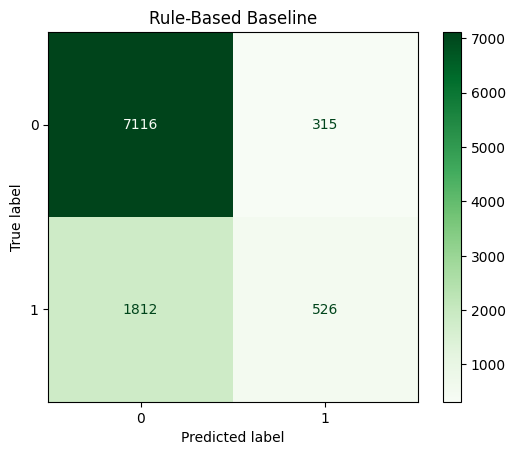

In [32]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rule,
    cmap="Greens"
)

plt.title("Rule-Based Baseline")

plt.show()

## Compare Both Baselines

In [33]:
comparison = pd.DataFrame(
    [majority_results, rule_results],
    index=[
        "Majority Baseline",
        "Rule Baseline"
    ]
)

comparison

,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
Majority Baseline,0.760672,0.000000,0.000000,0.000000,0.500000,0.239328
Rule Baseline,0.782270,0.625446,0.224979,0.330922,0.591294,0.326197


## Baseline Interpretation

The majority-class baseline achieved relatively high accuracy because most individuals belong to the low-income class. However, it completely failed to identify high-income individuals, resulting in zero precision, recall, and F1-score.

The rule-based classifier outperformed the majority baseline across all meaningful metrics. Using **capital-gain > 0** as the prediction rule improved accuracy, precision, recall, F1-score, ROC AUC, and PR AUC. This demonstrates that even a simple feature-based rule captures useful information about income.

Since the rule-based baseline achieved approximately **62.5% precision** , it establishes a meaningful benchmark for future machine learning models. Any practical model should exceed this precision while also substantially improving recall and F1-score. Achieving these improvements would enable the model to identify more high-income individuals without sacrificing prediction reliability, making it more valuable for targeted marketing applications.

## Error Analysis

In [34]:
test_results = X_test.copy()

test_results["Actual"] = y_test.values

test_results["Predicted"] = y_pred_rule.values

## False Positive

In [35]:
false_positives = test_results[
    (test_results["Actual"] == 0) &
    (test_results["Predicted"] == 1)
]

false_positives.sample(10, random_state=42)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Actual,Predicted
37136,22,Private,190968,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,2407,0,40,United-States,0,1
48796,66,Federal-gov,47358,10th,6,Married-civ-spouse,Craft-repair,Husband,White,Male,3471,0,40,United-States,0,1
45354,32,Private,123964,Some-college,10,Married-civ-spouse,Sales,Husband,White,Male,4386,0,50,United-States,0,1
17677,54,Private,398212,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,Black,Male,5013,0,40,United-States,0,1
23656,39,Local-gov,116666,HS-grad,9,Never-married,Protective-serv,Own-child,Amer-Indian-Eskimo,Male,4650,0,48,United-States,0,1
31952,39,Private,231141,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,2829,0,40,United-States,0,1
27437,25,Private,40512,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Male,3674,0,30,United-States,0,1
37691,74,NaN,33114,10th,6,Married-civ-spouse,NaN,Husband,Amer-Indian-Eskimo,Male,1797,0,30,United-States,0,1
14884,30,Private,119562,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,3942,0,40,United-States,0,1
25396,38,Private,51100,Bachelors,13,Divorced,Exec-managerial,Not-in-family,White,Male,3325,0,40,United-States,0,1


## False Negative

In [36]:
false_negatives = test_results[
    (test_results["Actual"] == 1) &
    (test_results["Predicted"] == 0)
]

false_negatives.sample(10, random_state=42)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Actual,Predicted
10804,38,Private,285890,Bachelors,13,Married-civ-spouse,Tech-support,Husband,Black,Male,0,0,55,United-States,1,0
13191,33,Private,236304,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,Black,Male,0,0,60,United-States,1,0
11819,51,Private,169785,Bachelors,13,Married-spouse-absent,Exec-managerial,Not-in-family,White,Female,0,0,60,United-States,1,0
30835,59,Private,70720,Bachelors,13,Divorced,Sales,Not-in-family,White,Male,0,0,55,United-States,1,0
25178,29,Private,137618,Some-college,10,Never-married,Other-service,Not-in-family,White,Female,0,0,41,United-States,1,0
35575,42,Private,373469,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,1,0
8035,31,Private,124483,Masters,14,Never-married,Adm-clerical,Not-in-family,Asian-Pac-Islander,Male,0,0,60,India,1,0
2626,53,Private,184176,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,50,United-States,1,0
5796,61,Self-emp-inc,190610,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,United-States,1,0
1655,30,Private,156015,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,1,0


## Error Analysis

### False Positives

Several individuals reported a positive capital gain but still belonged to the low-income class. This indicates that capital gain alone is not sufficient to determine annual income accurately. Other factors such as occupation, education, and working hours also influence income.

### False Negatives

Many individuals earning more than $50K reported no capital gain. These individuals may have high-paying jobs or advanced education but do not generate investment income. Consequently, the rule-based classifier fails to identify them.

### Observations from Sample

The sampled false negatives revealed several common patterns. Most individuals reported **zero capital gain**, despite actually belonging to the high-income class. Many also had **Bachelor's or Master's degrees**, worked **40–60 hours per week**, and held professional or managerial occupations such as **Tech-support**, **Exec-managerial**, and **Sales**. These findings indicate that high income is often associated with professional employment rather than investment income alone. Therefore, relying solely on **capital-gain** as the prediction rule causes many high-income individuals to be misclassified. Incorporating additional features such as education level, occupation, and hours worked is likely to improve future model performance.

## Data and Feature Improvements

The following improvements should be implemented in future iterations:

1. Handle missing values in **workclass**, **occupation**, and **native-country**.
2. Apply One-Hot Encoding to categorical features.
3. Transform highly skewed variables such as **capital-gain** and **capital-loss** using logarithmic scaling.
4. Engineer additional features by combining education, occupation, and working hours.
5. Train more advanced machine learning models such as Logistic Regression, Decision Trees, Random Forests, or XGBoost.
6. Perform hyperparameter tuning using cross-validation while keeping the hold-out test set untouched.

## Primary Metric for Future Optimization

Precision (Precision@top-k) will remain the primary evaluation metric throughout this project because the business objective is to minimize unnecessary marketing outreach. The rule-based classifier achieved a precision of approximately **62.5%**, demonstrating that meaningful predictions can be made using simple business rules.
Since the rule-based baseline achieved 62.5% precision, any practical ML model should exceed this precision while also improving recall and F1-score.

Future machine learning models should improve precision while also increasing recall and F1-score, enabling more accurate identification of high-income individuals without substantially increasing false positive predictions.

# Final Conclusion

This project established a complete baseline machine learning workflow for predicting whether an individual's annual income exceeds **$50,000**.

Key accomplishments include:

- Defined a clear business objective and selected Precision@top-k as the primary evaluation metric.
- Performed exploratory data analysis and identified missing values and class imbalance.
- Created a reproducible hold-out train/test split.
- Developed and evaluated two baseline classifiers.
- Conducted an initial error analysis and identified opportunities for feature engineering and model improvement.

The **Rule-Based Baseline** outperformed the Majority-Class Baseline, demonstrating that even simple domain knowledge can improve predictive performance. These results provide a strong benchmark for future machine learning models such as Logistic Regression, Random Forest, and Gradient Boosting.